Dataset Shape: (891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

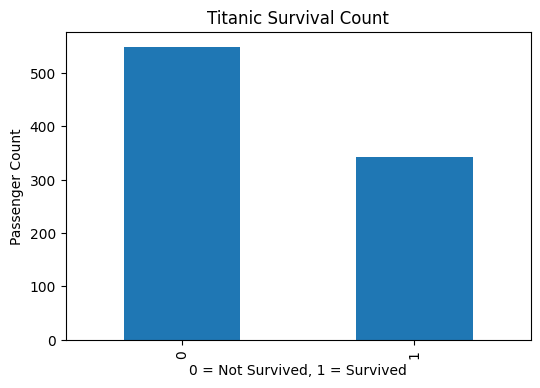

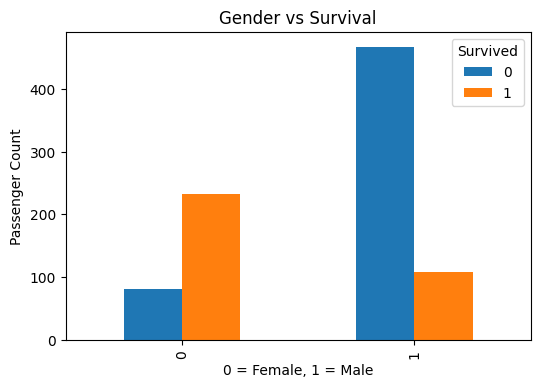

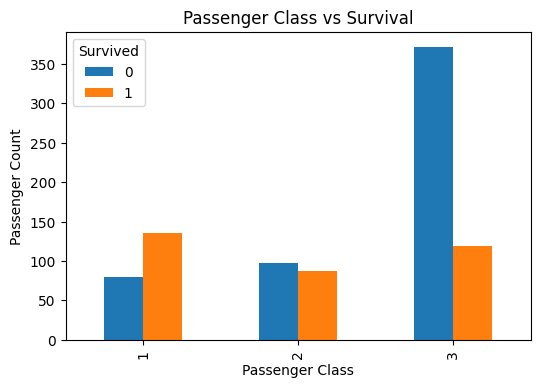

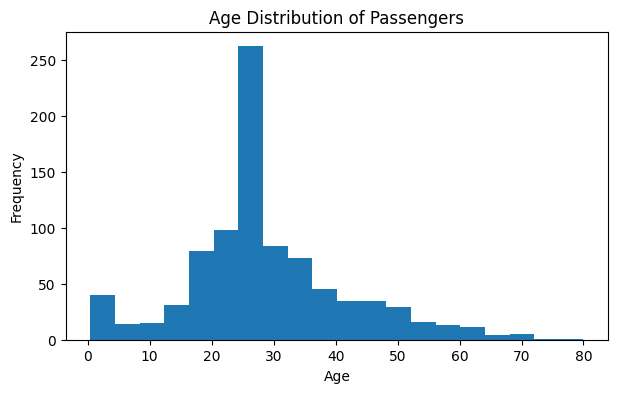

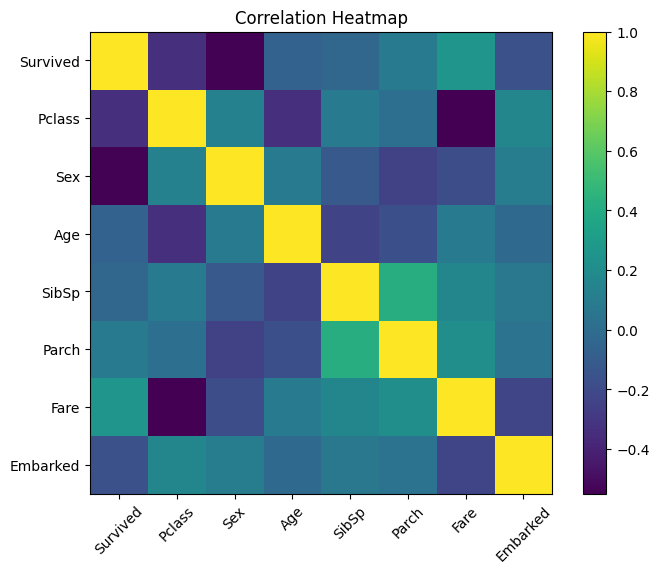


Logistic Regression
Accuracy: 80.45 %

Confusion Matrix:
[[90 15]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Decision Tree
Accuracy: 78.21 %

Confusion Matrix:
[[83 22]
 [17 57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179


Random Forest
Accuracy: 82.12 %

Confusion Matrix:
[[92 13]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support



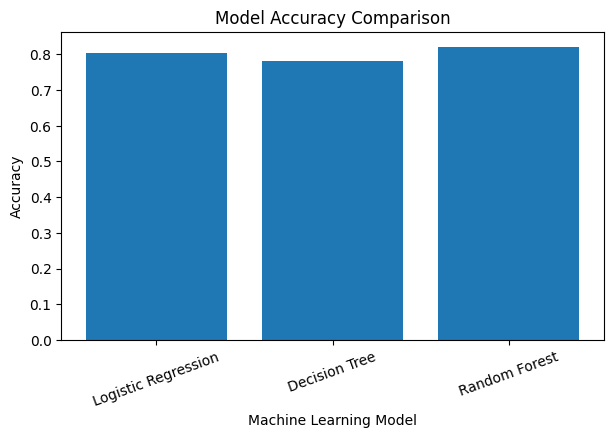


Best Model: Random Forest

Final Model Accuracy: 82.12 %

Feature Importance:
    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


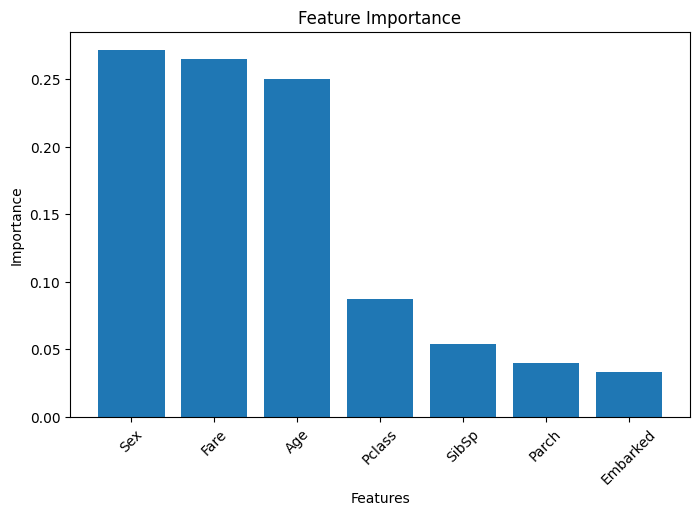


Sample Passenger Data:
   Pclass  Sex  Age  SibSp  Parch  Fare  Embarked
0       3    1   22      1      0  7.25         2
Prediction: Passenger Did Not Survive


In [3]:
# CODSOFT Data Science Internship
# Task 1: Titanic Survival Prediction - Professional Version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop unnecessary columns
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Encode categorical data
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])          # female=0, male=1
df["Embarked"] = le.fit_transform(df["Embarked"])

print("\nCleaned Dataset:")
print(df.head())

# EDA Graph 1: Survival Count
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Titanic Survival Count")
plt.xlabel("0 = Not Survived, 1 = Survived")
plt.ylabel("Passenger Count")
plt.show()

# EDA Graph 2: Gender vs Survival
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar", figsize=(6,4))
plt.title("Gender vs Survival")
plt.xlabel("0 = Female, 1 = Male")
plt.ylabel("Passenger Count")
plt.show()

# EDA Graph 3: Passenger Class vs Survival
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar", figsize=(6,4))
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()

# EDA Graph 4: Age Distribution
plt.figure(figsize=(7,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# EDA Graph 5: Correlation Heatmap
corr = df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", round(acc * 100, 2), "%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Model Comparison
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(7,4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# Best Model
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print("\nBest Model:", best_model_name)

# Train final Random Forest model
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("\nFinal Model Accuracy:", round(accuracy_score(y_test, final_pred) * 100, 2), "%")

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# Sample Prediction
sample_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],       # 0 = Female, 1 = Male
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [2]
})

prediction = final_model.predict(sample_passenger)

print("\nSample Passenger Data:")
print(sample_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")